# 03 Clasificacion

El objetivo es predecir `objetivo`: abandono, matriculado o graduado.

Comparo dos momentos:

- `early`: antes de tener notas del primer semestre.
- `sem1`: usando tambien informacion del primer semestre.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.knn_propio import knn
from src.logistic_regresion_propia import LogisticRegressorOVR
from src.preprocess_base import (
    cargar_data,
    limpieza_basica,
    permutar_filas,
    tratar_ceros_notas_sin_evaluacion,
)
from src.preprocess_clasificacion import get_classification_dataset
from src.utils import (
    PROJECT_PALETTE,
    adaptar_dataframe_a_sklearn,
    annotate_bars,
    plot_confusion_heatmap,
    set_project_style,
)
from src.validacion_cruzada_propia import cross_validation_supervised

warnings.filterwarnings("ignore", message="Found unknown categories in columns")
pd.set_option("display.max_columns", None)
set_project_style()
print("Proyecto:", PROJECT_ROOT.name)


Proyecto: student-academic-performance


## Planteamiento

- No uso variables del segundo semestre.
- Comparo baseline, kNN propio y regresion logistica OVR propia.
- Uso accuracy y F1 macro, porque hay tres clases y no estan igual de representadas.
- El test se deja separado desde el principio.


In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
UNKNOWN_AS_MISSING = False
CATEGORICAL_MISSING_STRATEGY = "constant"
CATEGORICAL_MISSING_FILL_VALUE = "valor_faltante"

KNN_K = 5
KNN_P = 2

LR_LEARNING_RATE = 0.05
LR_NUM_ITERATIONS = 3000
LR_PENALTY = "elasticnet"
LR_L1_RATIO = 0.5
LR_C = 1.0


def build_classification_preprocessor(
    X_train,
    categorical_missing_strategy=CATEGORICAL_MISSING_STRATEGY,
):
    numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
    categorical_cols = X_train.select_dtypes(exclude="number").columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    if categorical_missing_strategy == "constant":
        categorical_imputer = SimpleImputer(
            strategy="constant",
            fill_value=CATEGORICAL_MISSING_FILL_VALUE,
        )
    elif categorical_missing_strategy == "most_frequent":
        categorical_imputer = SimpleImputer(strategy="most_frequent")
    else:
        raise ValueError("categorical_missing_strategy debe ser 'constant' o 'most_frequent'.")

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", categorical_imputer),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )
    return preprocessor


def prepare_classification_data(
    stage,
    unknown_as_missing=UNKNOWN_AS_MISSING,
    categorical_missing_strategy=CATEGORICAL_MISSING_STRATEGY,
):
    df = cargar_data()
    df = permutar_filas(df, random_state=RANDOM_STATE)
    df = limpieza_basica(df, desconocido_es_nan=unknown_as_missing)
    df = tratar_ceros_notas_sin_evaluacion(df)
    df = df.convert_dtypes()
    df = adaptar_dataframe_a_sklearn(df)

    X, y = get_classification_dataset(df, stage=stage)
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    preprocessor = build_classification_preprocessor(
        X_train,
        categorical_missing_strategy=categorical_missing_strategy,
    )
    X_train_prepared = preprocessor.fit_transform(X_train)
    X_test_prepared = preprocessor.transform(X_test)

    return {
        "df": df,
        "X": X,
        "y": y,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "preprocessor": preprocessor,
        "X_train_prepared": X_train_prepared,
        "X_test_prepared": X_test_prepared,
    }


def fit_logistic_model(X_train_prepared, y_train):
    model = LogisticRegressorOVR()
    model.fit(
        X_train_prepared,
        y_train.to_numpy(),
        learning_rate=LR_LEARNING_RATE,
        num_iterations=LR_NUM_ITERATIONS,
        penalty=LR_PENALTY,
        l1_ratio=LR_L1_RATIO,
        C=LR_C,
        verbose=False,
    )
    return model


classification_scorers = {
    "accuracy": lambda yt, yp: accuracy_score(yt, yp),
    "f1_macro": lambda yt, yp: f1_score(yt, yp, average="macro"),
    "recall_matriculado": lambda yt, yp: recall_score(yt, yp, labels=["matriculado"], average="macro", zero_division=0),
}
logistic_fit_params = dict(learning_rate=LR_LEARNING_RATE, num_iterations=LR_NUM_ITERATIONS,
    penalty=LR_PENALTY, l1_ratio=LR_L1_RATIO, C=LR_C)

def evaluate_logistic_cv(data):
    _, summary = cross_validation_supervised(
        model_factory=lambda: LogisticRegressorOVR(), X=data["X_train"], y=data["y_train"],
        preprocessor=data["preprocessor"], n_folds=CV_FOLDS,
        scorers=classification_scorers, fit_params=logistic_fit_params, random_state=RANDOM_STATE)
    return summary.set_index("metric")["mean"].to_dict()


## Comparacion `early` y `sem1`

Primero compruebo si merece la pena usar informacion del primer semestre.


,stage,accuracy,f1_macro,recall_matriculado
0,early,0.654,0.517,0.093
1,sem1,0.747,0.636,0.211


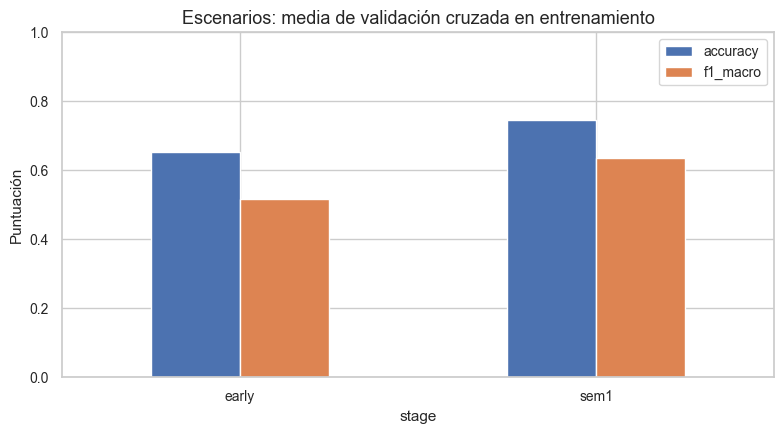

In [3]:
stage_rows = []
for stage in ["early", "sem1"]:
    stage_data = prepare_classification_data(stage)
    stage_rows.append({"stage": stage, **evaluate_logistic_cv(stage_data)})
df_stage_comparison = pd.DataFrame(stage_rows)
display(df_stage_comparison.round(3))
selected_stage = df_stage_comparison.sort_values("f1_macro", ascending=False).iloc[0]["stage"]
ax = df_stage_comparison.set_index("stage")[["accuracy", "f1_macro"]].plot.bar(rot=0, ylim=(0, 1))
ax.set_title("Escenarios: media de validación cruzada en entrenamiento")
ax.set_ylabel("Puntuación")
plt.tight_layout()
plt.show()


## Sensibilidad con missing categorico

Pruebo dos decisiones:

- mantener `desconocido` como categoria o pasarlo a missing;
- rellenar missing categoricos con `valor_faltante` o con la moda.

La idea es ver si esta decision cambia mucho el resultado.


,configuracion,accuracy,f1_macro,recall_matriculado
3,desconocido_nan + moda,0.750,0.638,0.211
0,desconocido_categoria + missing_explicito,0.747,0.636,0.211
1,desconocido_nan + missing_explicito,0.747,0.636,0.211
2,desconocido_categoria + moda,0.747,0.636,0.211


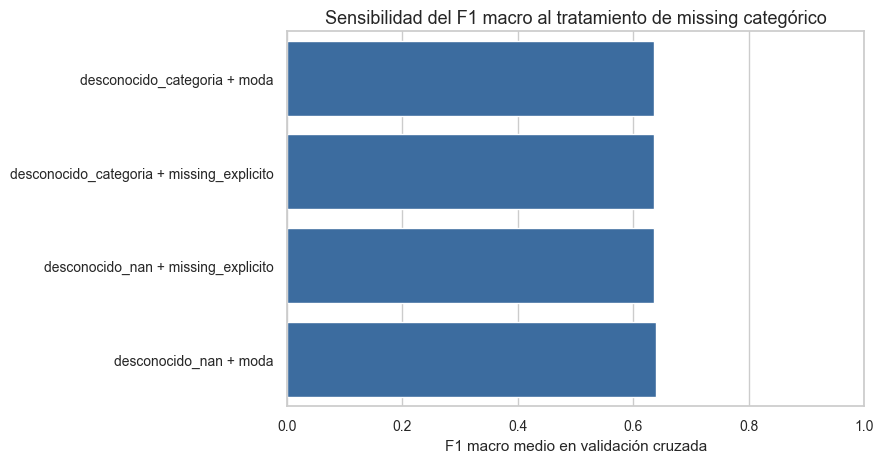

In [4]:
sensitivity_configs = [
    {
        "configuracion": "desconocido_categoria + missing_explicito",
        "unknown_as_missing": False,
        "categorical_missing_strategy": "constant",
    },
    {
        "configuracion": "desconocido_nan + missing_explicito",
        "unknown_as_missing": True,
        "categorical_missing_strategy": "constant",
    },
    {
        "configuracion": "desconocido_categoria + moda",
        "unknown_as_missing": False,
        "categorical_missing_strategy": "most_frequent",
    },
    {
        "configuracion": "desconocido_nan + moda",
        "unknown_as_missing": True,
        "categorical_missing_strategy": "most_frequent",
    },
]

sensitivity_rows = []
for config in sensitivity_configs:
    data_sens = prepare_classification_data(
        selected_stage,
        unknown_as_missing=config["unknown_as_missing"],
        categorical_missing_strategy=config["categorical_missing_strategy"],
    )
    sensitivity_rows.append({"configuracion": config["configuracion"], **evaluate_logistic_cv(data_sens)})

df_sensibilidad_missing = pd.DataFrame(sensitivity_rows).sort_values("f1_macro", ascending=False)
display(df_sensibilidad_missing.round(3))

plt.figure(figsize=(9, 4.8))
plot_df = df_sensibilidad_missing.sort_values("f1_macro")
sns.barplot(
    data=plot_df,
    y="configuracion",
    x="f1_macro",
    color=PROJECT_PALETTE["primary"],
)
plt.title("Sensibilidad del F1 macro al tratamiento de missing categórico")
plt.xlabel("F1 macro medio en validación cruzada")
plt.ylabel("")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


### Lectura

La sensibilidad se mide exclusivamente dentro de entrenamiento. Se mantiene la configuración principal por su interpretación: `desconocido` como categoría y un valor explícito para los datos faltantes. No se optimiza esta decisión contra el test.


## Escenario principal

El escenario se selecciona por F1 macro medio en validación cruzada de entrenamiento. El test se utiliza al final para comparar las configuraciones ya fijadas.


In [5]:
STAGE = selected_stage
data = prepare_classification_data(STAGE)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
preprocessor = data["preprocessor"]
X_train_prepared = data["X_train_prepared"]
X_test_prepared = data["X_test_prepared"]

print("Stage elegido:", STAGE)
print("X_train original:", X_train.shape)
print("X_test original:", X_test.shape)
print("X_train preparado:", X_train_prepared.shape)
print("X_test preparado:", X_test_prepared.shape)
print("\nDistribucion de clases en train:")
display(y_train.value_counts(normalize=True).mul(100).round(2).rename("porcentaje"))


Stage elegido: sem1
X_train original: (3539, 30)
X_test original: (885, 30)
X_train preparado: (3539, 240)
X_test preparado: (885, 240)

Distribucion de clases en train:


objetivo
graduado       49.93
abandono       32.13
matriculado    17.94
Name: porcentaje, dtype: float64

## Validacion cruzada

Repito la comparacion en varios folds usando solo train. Esto sirve para no depender demasiado de un unico split.


,metric,mean,std,modelo
0,accuracy,0.666,0.009,kNN
1,f1_macro,0.543,0.013,kNN
2,accuracy,0.747,0.017,logistica_ovr
3,f1_macro,0.636,0.016,logistica_ovr


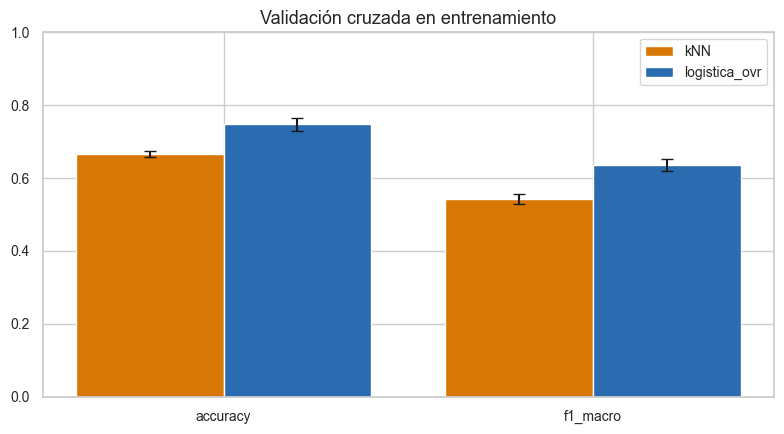

In [6]:
classification_scorers = {
    "accuracy": lambda y_true, y_pred: accuracy_score(y_true, y_pred),
    "f1_macro": lambda y_true, y_pred: f1_score(y_true, y_pred, average="macro"),
}

_, cv_knn_summary = cross_validation_supervised(
    model_factory=lambda: knn(),
    X=X_train,
    y=y_train,
    preprocessor=preprocessor,
    n_folds=CV_FOLDS,
    task="classification",
    scorers=classification_scorers,
    fit_params={"k": KNN_K, "p": KNN_P},
    random_state=RANDOM_STATE,
)

_, cv_log_summary = cross_validation_supervised(
    model_factory=lambda: LogisticRegressorOVR(),
    X=X_train,
    y=y_train,
    preprocessor=preprocessor,
    n_folds=CV_FOLDS,
    task="classification",
    scorers=classification_scorers,
    fit_params={
        "learning_rate": LR_LEARNING_RATE,
        "num_iterations": LR_NUM_ITERATIONS,
        "penalty": LR_PENALTY,
        "l1_ratio": LR_L1_RATIO,
        "C": LR_C,
    },
    random_state=RANDOM_STATE,
)

cv_knn_summary["modelo"] = "kNN"
cv_log_summary["modelo"] = "logistica_ovr"
cv_comparison = pd.concat([cv_knn_summary, cv_log_summary], ignore_index=True)
display(cv_comparison.round(3))


fig, ax = plt.subplots(figsize=(8, 4.5))
metrics = ["accuracy", "f1_macro"]
for offset, model_name, color in [(-0.2, "kNN", PROJECT_PALETTE["accent"]), (0.2, "logistica_ovr", PROJECT_PALETTE["primary"])]:
    part = cv_comparison[cv_comparison["modelo"] == model_name].set_index("metric").loc[metrics]
    ax.bar(np.arange(2) + offset, part["mean"], width=0.4, yerr=part["std"], capsize=4, label=model_name, color=color)
ax.set_xticks(np.arange(2), metrics)
ax.set_ylim(0, 1)
ax.set_title("Validación cruzada en entrenamiento")
ax.legend()
plt.tight_layout()
plt.show()
selected_model = cv_comparison[cv_comparison["metric"] == "f1_macro"].sort_values("mean", ascending=False).iloc[0]["modelo"]


,k,cv_accuracy_mean,cv_f1_macro_mean
0,1,0.618,0.549
1,3,0.642,0.549
2,5,0.666,0.543
3,7,0.667,0.543
4,9,0.672,0.548
5,11,0.677,0.552
6,15,0.675,0.542


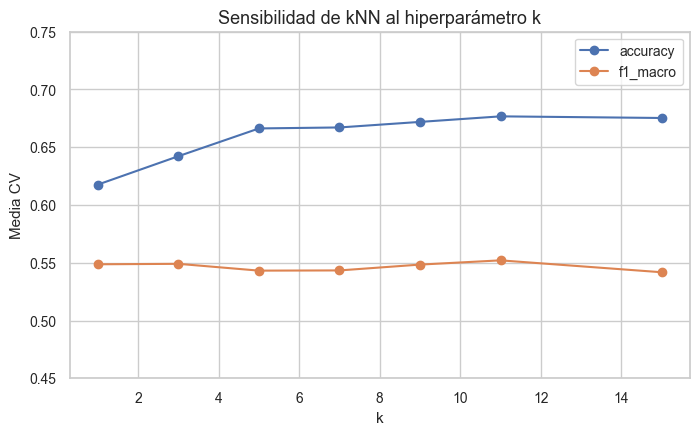

In [7]:
k_values = [1, 3, 5, 7, 9, 11, 15]
resultados_cv_knn = []

for k_value in k_values:
    _, cv_summary_k = cross_validation_supervised(
        model_factory=lambda: knn(),
        X=X_train,
        y=y_train,
        preprocessor=preprocessor,
        n_folds=CV_FOLDS,
        task="classification",
        scorers=classification_scorers,
        fit_params={"k": k_value, "p": KNN_P},
        random_state=RANDOM_STATE,
    )

    resumen = cv_summary_k.set_index("metric")["mean"].to_dict()
    resultados_cv_knn.append(
        {
            "k": k_value,
            "cv_accuracy_mean": resumen["accuracy"],
            "cv_f1_macro_mean": resumen["f1_macro"],
        }
    )

df_resultados_cv_knn = pd.DataFrame(resultados_cv_knn).sort_values("k")
display(df_resultados_cv_knn.round(3))

plt.figure(figsize=(8, 4.5))
plt.plot(df_resultados_cv_knn["k"], df_resultados_cv_knn["cv_accuracy_mean"], marker="o", label="accuracy")
plt.plot(df_resultados_cv_knn["k"], df_resultados_cv_knn["cv_f1_macro_mean"], marker="o", label="f1_macro")
plt.title("Sensibilidad de kNN al hiperparámetro k")
plt.xlabel("k")
plt.ylabel("Media CV")
plt.ylim(0.45, 0.75)
plt.legend()
plt.show()


Informe por clase del modelo elegido:


,modelo,accuracy,f1_macro
2,logistica_ovr,0.736,0.611
1,kNN (k=5),0.663,0.541
0,baseline_mayoritaria,0.499,0.222


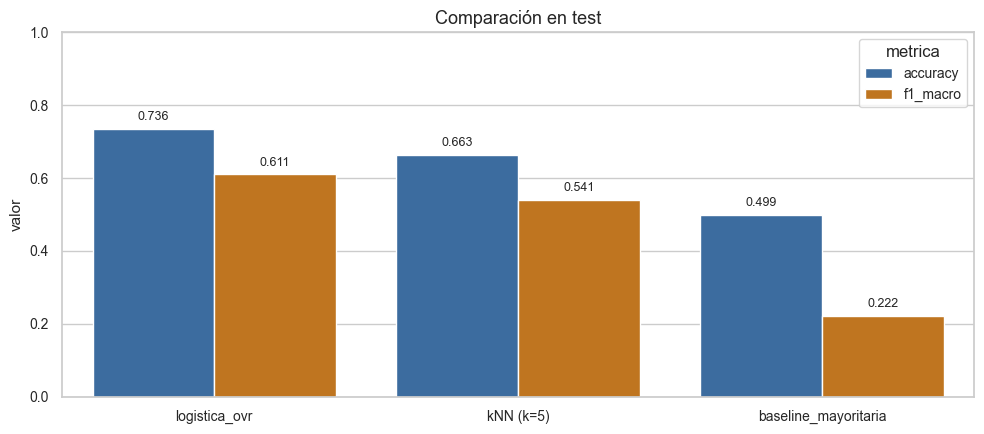

,precision,recall,f1-score,support
abandono,0.792,0.739,0.765,284.000
graduado,0.737,0.939,0.826,442.000
matriculado,0.456,0.164,0.241,159.000
accuracy,0.736,0.736,0.736,0.736
macro avg,0.662,0.614,0.611,885.000
weighted avg,0.704,0.736,0.701,885.000


In [8]:
baseline_class = y_train.mode().iloc[0]
y_pred_baseline = np.repeat(baseline_class, len(y_test))

knn_model = knn()
knn_model.fit(X_train_prepared, y_train.to_numpy(), k=KNN_K, p=KNN_P)
y_pred_knn = knn_model.predict(X_test_prepared)

logreg_model = fit_logistic_model(X_train_prepared, y_train)
y_pred_logreg = logreg_model.predict(X_test_prepared)

resultados_test = pd.DataFrame(
    [
        {
            "modelo": "baseline_mayoritaria",
            "accuracy": accuracy_score(y_test, y_pred_baseline),
            "f1_macro": f1_score(y_test, y_pred_baseline, average="macro"),
        },
        {
            "modelo": f"kNN (k={KNN_K})",
            "accuracy": accuracy_score(y_test, y_pred_knn),
            "f1_macro": f1_score(y_test, y_pred_knn, average="macro"),
        },
        {
            "modelo": "logistica_ovr",
            "accuracy": accuracy_score(y_test, y_pred_logreg),
            "f1_macro": f1_score(y_test, y_pred_logreg, average="macro"),
        },
    ]
).sort_values("f1_macro", ascending=False)

display(resultados_test.round(3))

plot_df = resultados_test.melt(id_vars="modelo", var_name="metrica", value_name="valor")
plt.figure(figsize=(10, 4.5))
ax = sns.barplot(
    data=plot_df,
    x="modelo",
    y="valor",
    hue="metrica",
    palette=[PROJECT_PALETTE["primary"], PROJECT_PALETTE["accent"]],
)
ax.set_title("Comparación en test")
ax.set_xlabel("")
ax.set_ylim(0, 1)
annotate_bars(ax)
plt.tight_layout()
plt.show()

print("Informe por clase del modelo elegido:")
reporte_logreg = pd.DataFrame(classification_report(y_test, y_pred_logreg, output_dict=True)).T.round(3)
display(reporte_logreg)


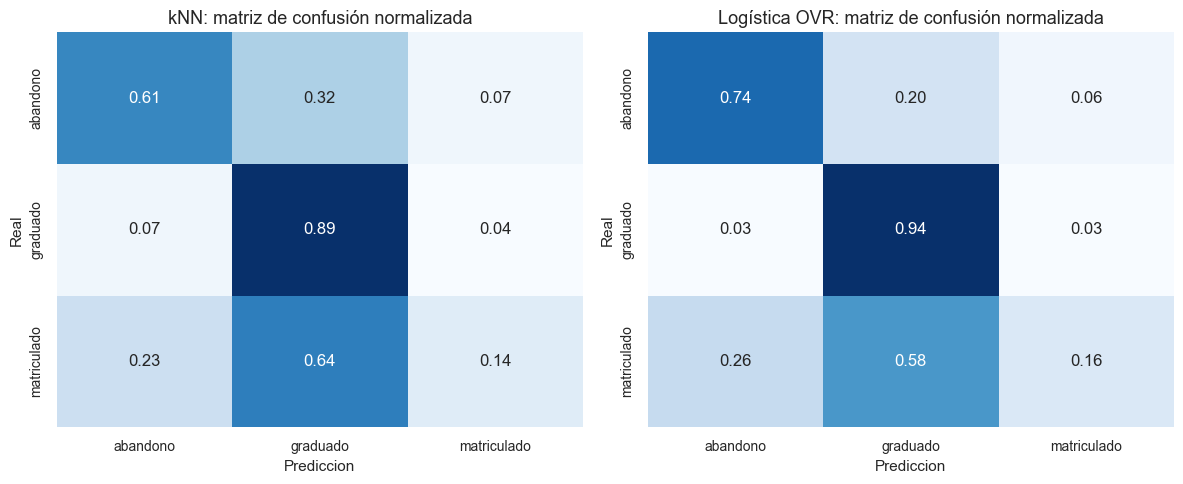

In [9]:
class_labels = sorted(y_train.unique().tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion_heatmap(
    y_test,
    y_pred_knn,
    labels=class_labels,
    title="kNN: matriz de confusión normalizada",
    ax=axes[0],
)
plot_confusion_heatmap(
    y_test,
    y_pred_logreg,
    labels=class_labels,
    title="Logística OVR: matriz de confusión normalizada",
    ax=axes[1],
)
plt.tight_layout()
plt.show()


## Interpretacion

Con la regresion logistica puedo mirar que variables empujan mas hacia cada clase. Lo uso solo como apoyo, no como causalidad.


,clase,tipo,feature,coeficiente
0,abandono,positivo,cat__matricula_al_dia_no,1.156719
1,abandono,positivo,num__asignaturas_1sem_matriculadas,0.844600
2,abandono,positivo,cat__curso_educacion_basica,0.672710
3,abandono,positivo,num__asignaturas_1sem_convalidadas,0.569868
4,abandono,positivo,cat__ocupacion_madre_estudiante,0.449290
5,abandono,positivo,cat__curso_equicultura,0.417439
6,abandono,positivo,cat__cualificacion_madre_desconocido,0.402181
7,abandono,positivo,cat__curso_turismo,0.346051
8,abandono,negativo,num__asignaturas_1sem_aprobadas,-2.142936
9,abandono,negativo,cat__matricula_al_dia_si,-1.177743


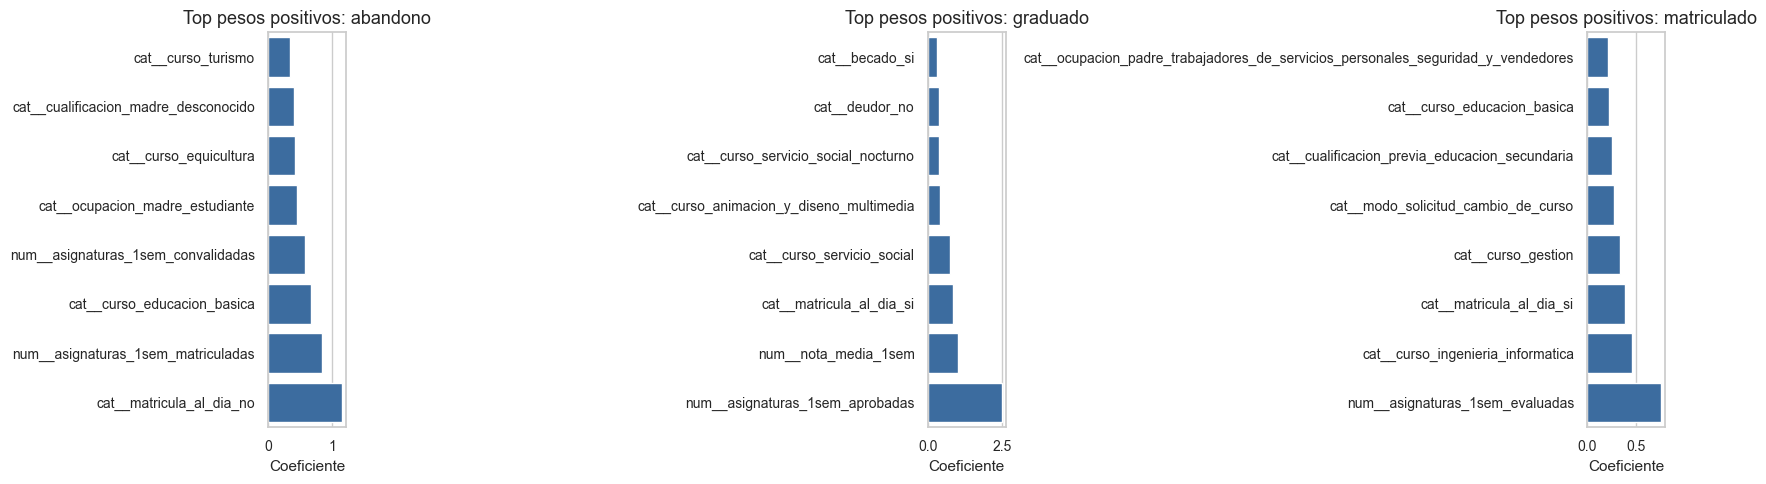

In [10]:
feature_names = preprocessor.get_feature_names_out()

top_feature_rows = []
for class_label, binary_model in logreg_model.models_.items():
    coef_series = pd.Series(binary_model.weights, index=feature_names)

    top_pos = coef_series.sort_values(ascending=False).head(8)
    top_neg = coef_series.sort_values().head(8)

    for feature, value in top_pos.items():
        top_feature_rows.append(
            {"clase": class_label, "tipo": "positivo", "feature": feature, "coeficiente": value}
        )
    for feature, value in top_neg.items():
        top_feature_rows.append(
            {"clase": class_label, "tipo": "negativo", "feature": feature, "coeficiente": value}
        )

top_features_df = pd.DataFrame(top_feature_rows)
display(top_features_df.head(20))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=False)
for ax, class_label in zip(axes, logreg_model.classes_):
    subset = (
        top_features_df[
            (top_features_df["clase"] == class_label) & (top_features_df["tipo"] == "positivo")
        ]
        .sort_values("coeficiente")
    )
    sns.barplot(data=subset, x="coeficiente", y="feature", color=PROJECT_PALETTE["primary"], ax=ax)
    ax.set_title(f"Top pesos positivos: {class_label}")
    ax.set_xlabel("Coeficiente")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [11]:
chosen_test_name = "logistica_ovr" if selected_model == "logistica_ovr" else f"kNN (k={KNN_K})"
test_row = resultados_test.set_index("modelo").loc[chosen_test_name]
cv_row = cv_comparison[cv_comparison["modelo"] == selected_model].set_index("metric")["mean"]
resumen_final_clasificacion = pd.DataFrame([
    {"apartado": "test", "modelo": chosen_test_name, "accuracy": test_row["accuracy"], "f1_macro": test_row["f1_macro"]},
    {"apartado": "cv_train", "modelo": chosen_test_name, "accuracy": cv_row["accuracy"], "f1_macro": cv_row["f1_macro"]},
])
display(resumen_final_clasificacion.round(3))
print("Modelo seleccionado en CV:", chosen_test_name)


Modelo seleccionado en CV: logistica_ovr


,apartado,modelo,accuracy,f1_macro
0,test,logistica_ovr,0.736,0.611
1,cv_train,logistica_ovr,0.747,0.636


## Conclusiones y alcance

Los resultados anteriores comparan escenarios y modelos propios. La selección principal usa validación cruzada sobre entrenamiento; el análisis de k es una sensibilidad y se conserva k=5 para la comparación predefinida. El análisis de coeficientes describe la regresión logística, sin atribuir causalidad.

Esta revisión reutiliza un dataset y un split ya explorados en la entrega académica: el test es una evaluación retrospectiva, no una validación externa nueva. Harían falta nuevas cohortes para estimar la generalización temporal.


## Exportar resultados

Tablas reproducibles para el resumen del repositorio.

In [12]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
resultados_test.to_csv(RESULTS_DIR / "classification_test.csv", index=False)
cv_comparison.to_csv(RESULTS_DIR / "classification_cv.csv", index=False)
resumen_final_clasificacion.to_csv(RESULTS_DIR / "classification_summary.csv", index=False)
df_stage_comparison.to_csv(RESULTS_DIR / "classification_stages_cv.csv", index=False)
df_sensibilidad_missing.to_csv(RESULTS_DIR / "classification_missing_cv.csv", index=False)
